# 07 - Phase 2: power and pre-trends

Everything in this notebook is fixed **before** any treatment effect is estimated. It is the
phase 2 equivalent of notebook 03, and it exists for the same reason: with three pre-periods
and two post-periods, the design can produce a null that means "no effect" or a null that
means "could not have seen one", and those must be told apart by a threshold chosen in
advance rather than after the fact.

Three things are settled here:

1. **The minimum detectable effect** for each outcome, on this window.
2. **Whether pre-trends are flat** on `attraction` and `retention` directly, which
   `DESIGN.md` 14.4 requires because parallel trends in a ratio is neither implied by nor
   implies parallel trends in its components.
3. **The specification**: outcome, comparison group, estimator, inference.

**The outcomes** (`DESIGN.md` 14.3), all from the Fachserie matrix:

| name | definition | role |
|---|---|---|
| `attraction` | `log(german_location / origin)` | **primary**, in log points, comparable with phase 1 |
| `retention` | `stayers / origin` | second outcome, the most direct test of diversion |
| `ni_per1k` | `1000 * net_inflow / origin` | retained robustness variant, known to be underpowered |

`origin` is also carried on its own: it is the participation margin and answers the
deterrence half of the question.

In [1]:
import sys, glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

def find_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "data" / "processed" / "panel.parquet").exists():
            return cand
    raise FileNotFoundError("panel.parquet not found. Run: py src/build_panel.py")

ROOT = find_root(); sys.path.insert(0, str(ROOT))
from src import fachserie as fsx

FIG = ROOT / "results" / "figures"; TAB = ROOT / "results" / "tables"
FIG.mkdir(parents=True, exist_ok=True); TAB.mkdir(parents=True, exist_ok=True)
plt.rcParams["figure.figsize"] = (11, 5.5)
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3

FIRST_FEE  = 2006          # WS 2006/07, Nordrhein-Westfalen and Niedersachsen
WINDOW_END = 2007          # WS 2007/08; Hessen abolishes from WS 2008/09
WEST_NEVER = ["01", "04", "07"]        # Schleswig-Holstein, Bremen, Rheinland-Pfalz
CITY       = ["02", "04", "11"]        # Hamburg, Bremen, Berlin

# selected by semester, not by extension: the folder also holds the
# phase 3 volumes, and Destatis switched to .xlsx from WS 2013/14
VOLUMES = fsx.select_volumes(ROOT / "data" / "raw" / "fachserie", 2003, 2007)
panel = fsx.build_panel(VOLUMES)

p1 = pd.read_parquet(ROOT / "data" / "processed" / "panel.parquet")
p1 = p1[["state_code", "year", "ever_treated", "intro_year", "treated", "east"]]
d = panel.merge(p1, on=["state_code", "year"], how="left")

d["ni_per1k"] = 1000 * d.net_inflow / d.origin
d["log_origin"] = np.log(d.origin)
d["rel"] = np.where(d.ever_treated == 1, d.year - d.intro_year, np.nan)
pre = d[d.year < FIRST_FEE].copy()

OUTCOMES = {"attraction": "log(German location / origin)",
            "retention": "stayers / origin",
            "log_origin": "log origin (participation)",
            "ni_per1k": "net inflow per 1 000 origin"}

print(f"panel   : {len(d)} rows, {d.state_code.nunique()} states, {d.year.min()}-{d.year.max()}")
print(f"treated : {int(d.groupby('state_code').ever_treated.first().sum())} states, "
      f"cohorts {sorted(d.loc[d.ever_treated==1,'intro_year'].unique().astype(int))}")
print(f"pre-treatment sample: {pre.year.nunique()} years ({pre.year.min()}-{pre.year.max()}), "
      f"{len(pre)} rows")

panel   : 80 rows, 16 states, 2003-2007
treated : 7 states, cohorts [np.int64(2006), np.int64(2007)]
pre-treatment sample: 3 years (2003-2005), 48 rows


## 1. Minimum detectable effect

Same formula as notebook 03, and the same logic: the residual standard deviation after
absorbing state and year effects, scaled by the number of treated and control units and by
the number of pre- and post-periods. It is computed on the **pre-treatment sample only**, so
no treatment-period information enters the threshold.

This is the number that decides how a null is read. An estimate smaller than the MDE cannot
be distinguished from zero by this design, whatever p-value is attached to it.

In [2]:
def mde(df, outcome, label, n_post=2, alpha=0.05, power=0.80):
    m = smf.ols(f"{outcome} ~ C(state_code) + C(year)", data=df).fit()
    sd = float(np.std(m.resid, ddof=1))
    n_t = int(df.loc[df.ever_treated == 1, "state_code"].nunique())
    n_c = int(df.loc[df.ever_treated == 0, "state_code"].nunique())
    n_pre = int(df.year.nunique())
    se = sd * np.sqrt((1 / n_t + 1 / n_c) * (1 / n_pre + 1 / n_post))
    z = stats.norm.ppf(1 - alpha / 2) + stats.norm.ppf(power)
    return {"outcome": label, "treated": n_t, "controls": n_c,
            "pre": n_pre, "post": n_post, "resid SD": sd, "MDE": z * se}

rows = [mde(pre, k, v) for k, v in OUTCOMES.items()]
m = pd.DataFrame(rows)
m["MDE, readable"] = [
    f"{100*(np.exp(x)-1):+.2f}%" if k in ("attraction", "log_origin")
    else (f"{x:.4f} ({100*x/pre.retention.mean():.1f}% of base)" if k == "retention"
          else f"{x:.1f} per 1 000")
    for k, x in zip(OUTCOMES, m["MDE"])]
print(m.to_string(index=False, float_format=lambda x: f"{x:9.4f}"))
m.to_csv(TAB / "07_mde.csv", index=False)

MDE_ATTRACTION = float(m.loc[m.outcome == OUTCOMES["attraction"], "MDE"].iloc[0])
MDE_RETENTION  = float(m.loc[m.outcome == OUTCOMES["retention"], "MDE"].iloc[0])
print(f"\nPRE-COMMITTED THRESHOLDS")
print(f"  attraction : {100*(np.exp(MDE_ATTRACTION)-1):.2f}%")
print(f"  retention  : {MDE_RETENTION:.4f} ({100*MDE_RETENTION/pre.retention.mean():.1f}% of base)")
print(f"\nPhase 1 estimated -6.28% on the location margin. If diversion accounts for all")
print(f"of it, `attraction` should move by about that much.")

                      outcome  treated  controls  pre  post  resid SD       MDE         MDE, readable
log(German location / origin)        7         9    3     2    0.0322    0.0415                +4.23%
             stayers / origin        7         9    3     2    0.0130    0.0168 0.0168 (2.7% of base)
   log origin (participation)        7         9    3     2    0.0193    0.0249                +2.52%
  net inflow per 1 000 origin        7         9    3     2   34.0011   43.8223        43.8 per 1 000

PRE-COMMITTED THRESHOLDS
  attraction : 4.23%
  retention  : 0.0168 (2.7% of base)

Phase 1 estimated -6.28% on the location margin. If diversion accounts for all
of it, `attraction` should move by about that much.


### Power under the alternative comparison groups

The same east-west collinearity as phase 1: all seven fee states are western, six of the nine
never-treated are eastern. The western-only group is the sharper test and the more
underpowered one, so its MDE is fixed here too rather than discovered later.

In [3]:
groups = {
    "all never-treated (9)": pre,
    "western never-treated (3)": pre[(pre.ever_treated == 1) |
                                     (pre.state_code.isin(WEST_NEVER))],
    "excluding city states": pre[~pre.state_code.isin(CITY)],
}
rows = []
for label, sub in groups.items():
    for k in ("attraction", "retention"):
        r = mde(sub, k, OUTCOMES[k])
        rows.append({"comparison group": label, "outcome": OUTCOMES[k],
                     "treated": r["treated"], "controls": r["controls"],
                     "MDE": r["MDE"],
                     "readable": f"{100*(np.exp(r['MDE'])-1):+.2f}%" if k == "attraction"
                                 else f"{r['MDE']:.4f}"})
g = pd.DataFrame(rows)
print(g.to_string(index=False, float_format=lambda x: f"{x:9.4f}"))
g.to_csv(TAB / "07_mde_by_group.csv", index=False)
print("\nA wider MDE for the western-only group is expected: three controls carry less")
print("information than nine. It is fixed in advance so that a null there can be read")
print("correctly rather than as evidence of no effect.")

         comparison group                       outcome  treated  controls       MDE readable
    all never-treated (9) log(German location / origin)        7         9    0.0415   +4.23%
    all never-treated (9)              stayers / origin        7         9    0.0168   0.0168
western never-treated (3) log(German location / origin)        7         3    0.0451   +4.62%
western never-treated (3)              stayers / origin        7         3    0.0243   0.0243
    excluding city states log(German location / origin)        6         7    0.0445   +4.55%
    excluding city states              stayers / origin        6         7    0.0177   0.0177

A wider MDE for the western-only group is expected: three controls carry less
information than nine. It is fixed in advance so that a null there can be read
correctly rather than as evidence of no effect.


## 2. Pre-trends

`DESIGN.md` 14.4 requires this to be tested on the derived outcomes **directly**. Parallel
trends in a ratio is not implied by parallel trends in its numerator and denominator, and
does not imply them either: two states whose components each diverge can have a stable ratio,
and two states with parallel components can have a diverging one.

With three pre-periods there are two pre-treatment differences per state, so this test is
weak by construction. That is stated here rather than discovered afterwards.

**Failure condition: a pre-trend slope significant at 5% on either the primary or the second
outcome.** That would mean the groups were already diverging before any fee existed.

In [4]:
def pretrend(df, outcome, label):
    x = df.copy()
    x["t"] = x.year - x.year.min()
    x["fee"] = x.ever_treated
    # the `fee` level term is absorbed by the state fixed effects, so only the
    # interaction is estimable: it is the difference in pre-period slope
    m = smf.ols(f"{outcome} ~ t + t:fee + C(state_code)", data=x).fit(
        cov_type="cluster", cov_kwds={"groups": x.state_code})
    c = m.params["t:fee"]; se = m.bse["t:fee"]; p = m.pvalues["t:fee"]
    return {"outcome": label, "slope/yr": c, "SE": se, "p": p,
            "over 3 yrs": 3 * c, "significant 5%": "YES - FAILS" if p < 0.05 else "no"}

pt = pd.DataFrame([pretrend(pre, k, v) for k, v in OUTCOMES.items()])
print(pt.to_string(index=False, float_format=lambda x: f"{x:9.4f}"))
pt.to_csv(TAB / "07_pretrends.csv", index=False)

fails = pt[pt["significant 5%"].str.startswith("YES")]
print(f"\nverdict: {'FAILS on ' + ', '.join(fails.outcome) if len(fails) else 'no pre-trend detected at 5%'}")
print("\nWith two pre-treatment differences per state this test has little power, so")
print("failing to reject is weak evidence. Section 3 puts the slope on the same scale")
print("as the MDE to show how large an undetected trend could be.")

                      outcome  slope/yr        SE         p  over 3 yrs significant 5%
log(German location / origin)    0.0058    0.0200    0.7722      0.0173             no
             stayers / origin   -0.0013    0.0089    0.8871     -0.0038             no
   log origin (participation)    0.0043    0.0135    0.7467      0.0130             no
  net inflow per 1 000 origin    5.3305   20.4730    0.7946     15.9914             no

verdict: no pre-trend detected at 5%

With two pre-treatment differences per state this test has little power, so
failing to reject is weak evidence. Section 3 puts the slope on the same scale
as the MDE to show how large an undetected trend could be.


### How large a pre-trend could hide here?

A pre-trend test that cannot reject is only reassuring if it could have rejected something
meaningful. The comparison that matters is between the trend the design could have detected
and the effect it is looking for.

In [5]:
comp = []
for k in ("attraction", "retention"):
    row = pt[pt.outcome == OUTCOMES[k]].iloc[0]
    det = 1.96 * row["SE"] * 3          # 3-year movement the test could reject
    mde_k = MDE_ATTRACTION if k == "attraction" else MDE_RETENTION
    comp.append({"outcome": OUTCOMES[k],
                 "observed 3-yr pre-move": row["over 3 yrs"],
                 "detectable 3-yr pre-move": det,
                 "MDE for the effect": mde_k,
                 "ratio detectable/MDE": det / mde_k})
cm = pd.DataFrame(comp)
print(cm.to_string(index=False, float_format=lambda x: f"{x:9.4f}"))
print("\nIf the last column is well above 1, a pre-trend large enough to generate the")
print("effect could pass this test unnoticed, and the pre-trend result carries little")
print("weight. If it is near or below 1, the test is informative.")

                      outcome  observed 3-yr pre-move  detectable 3-yr pre-move  MDE for the effect  ratio detectable/MDE
log(German location / origin)                  0.0173                    0.1174              0.0415                2.8316
             stayers / origin                 -0.0038                    0.0524              0.0168                3.1198

If the last column is well above 1, a pre-trend large enough to generate the
effect could pass this test unnoticed, and the pre-trend result carries little
weight. If it is near or below 1, the test is informative.


### Visual check

Group means by year, with the pre-period fitted separately. The eye is a poor test but a
good detector of the thing a slope test misses: a level shift, an outlier year, or one state
dragging a group.

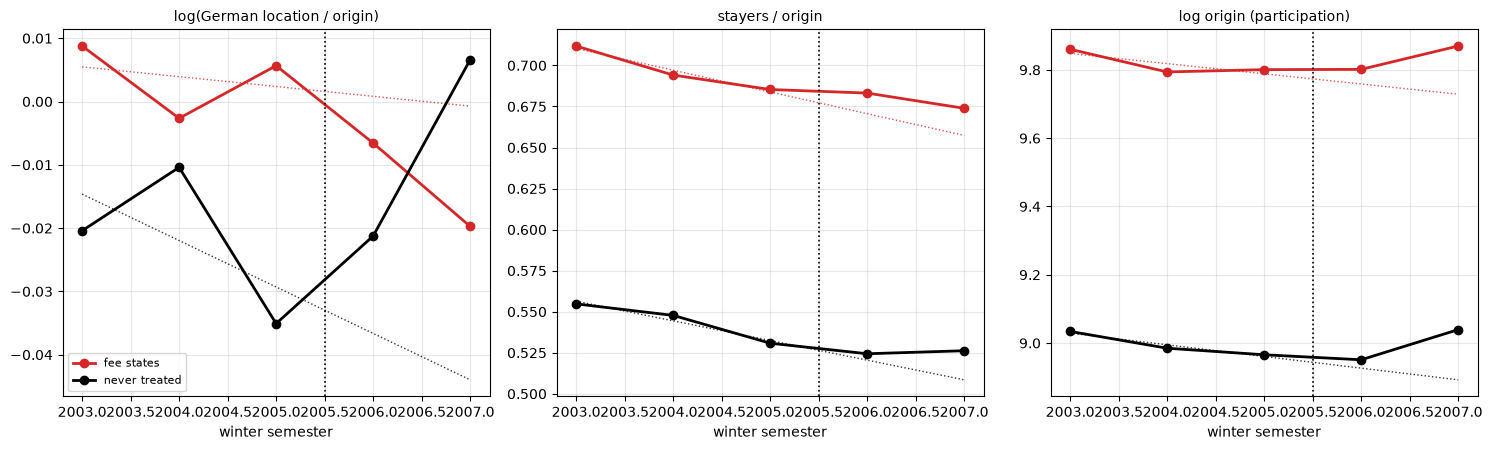

Dotted lines extrapolate the pre-period fit. Divergence before the vertical line
is a pre-trend; divergence only after it is what the design is looking for.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, k in zip(axes, ["attraction", "retention", "log_origin"]):
    for lab, sub in d.groupby(d.ever_treated.map({1: "fee states", 0: "never treated"})):
        gm = sub.groupby("year")[k].mean()
        col = "tab:red" if lab == "fee states" else "black"
        ax.plot(gm.index, gm.values, marker="o", color=col, lw=2, label=lab)
        pm = gm[gm.index < FIRST_FEE]
        b = np.polyfit(pm.index, pm.values, 1)
        ax.plot(gm.index, np.polyval(b, gm.index), color=col, ls=":", lw=1, alpha=0.8)
    ax.axvline(FIRST_FEE - 0.5, color="black", ls=":", lw=1.2)
    ax.set_title(OUTCOMES[k], fontsize=10); ax.set_xlabel("winter semester")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "18_phase2_pretrends.png", dpi=130, bbox_inches="tight")
plt.show()
print("Dotted lines extrapolate the pre-period fit. Divergence before the vertical line")
print("is a pre-trend; divergence only after it is what the design is looking for.")

## 3. Specification, fixed now

Everything below is committed before estimation and is not revisited in notebook 08.

In [7]:
spec = pd.DataFrame([
    ("primary outcome", "attraction = log(german_location / origin)"),
    ("second outcome", "retention = stayers / origin"),
    ("participation margin", "log(origin)"),
    ("robustness variant", "net_inflow per 1 000 origin (underpowered, reported)"),
    ("window", f"WS 2003/04 to WS {WINDOW_END}/{str(WINDOW_END+1)[-2:]}, 3 pre + 2 post"),
    ("comparison group", "all nine never-treated; western-only as co-primary"),
    ("estimator", "Callaway-Sant'Anna, never-treated controls; TWFE as diagnostic"),
    ("inference", "clustered by state, plus randomisation inference (16 clusters)"),
    ("MDE, attraction", f"{100*(np.exp(MDE_ATTRACTION)-1):.2f}%"),
    ("MDE, retention", f"{MDE_RETENTION:.4f}"),
    ("null rule", "an estimate below the MDE is reported as uninformative, not as no effect"),
], columns=["decision", "value"])
print(spec.to_string(index=False))
spec.to_csv(TAB / "07_specification.csv", index=False)

d.to_csv(TAB / "07_phase2_analysis_panel.csv", index=False)
print(f"\nwrote {TAB / '07_phase2_analysis_panel.csv'}")

            decision                                                                    value
     primary outcome                               attraction = log(german_location / origin)
      second outcome                                             retention = stayers / origin
participation margin                                                              log(origin)
  robustness variant                     net_inflow per 1 000 origin (underpowered, reported)
              window                                 WS 2003/04 to WS 2007/08, 3 pre + 2 post
    comparison group                       all nine never-treated; western-only as co-primary
           estimator           Callaway-Sant'Anna, never-treated controls; TWFE as diagnostic
           inference           clustered by state, plus randomisation inference (16 clusters)
     MDE, attraction                                                                    4.23%
      MDE, retention                                        

## What this notebook establishes

**The design can detect an effect of the size phase 1 implies, on all three substantive
outcomes. What it cannot do is rule out a pre-trend large enough to have generated one. Both
facts are fixed here, before any treatment effect is estimated.**

### 1. Minimum detectable effects, pre-committed

| outcome | pre-period residual SD | MDE |
|---|---|---|
| `attraction` = log(German location / origin) | 0.0322 | **+4.23%** |
| `retention` = stayers / origin | 0.0130 | **0.0168**, 2.7% of base |
| `log(origin)`, participation | 0.0193 | **+2.52%** |
| `net_inflow` per 1 000 origin | 34.00 | 43.8 per 1 000 |

Phase 1 estimated **-6.28%** on the location margin. If diversion accounts for all of it,
`attraction` should move by roughly that much, which is above the 4.23% this design can see.
**The window is adequate for the question**, which was not obvious from notebook 06's raw
group means and is the reason the outcome was rescaled (`DESIGN.md` 14.3).

The participation margin is the best powered of the three at 2.52%. That matters for the
deterrence half of the question: a null on `origin` will be a reasonably tight null, so
"participation did not move" is a claim this design can actually support rather than merely
fail to reject.

The original levels scaling confirms its own demotion: an MDE of 43.8 per 1 000 against an
observed movement around 24. It is retained and reported, not used.

### 2. Cost of the western-only comparison

| comparison group | `attraction` | `retention` |
|---|---|---|
| all never-treated (9) | +4.23% | 0.0168 |
| western never-treated (3) | +4.62% | 0.0243 |
| excluding city states | +4.55% | 0.0177 |

Less punishing than in phase 1. Dropping from nine controls to three widens the primary MDE
by only 0.4 percentage points, because the residual variance is similar in the smaller group
and most of the loss is in the cluster count rather than the noise. The western-only
specification is therefore a genuine co-primary here rather than a gesture: at 4.62% it too
sits below the effect phase 1 implies.

`retention` is the exception, widening from 0.0168 to 0.0243, so a null on retention under
western-only controls will be substantially weaker than under the full group.

### 3. No pre-trend detected, on any outcome

| outcome | slope per year | SE | p |
|---|---|---|---|
| `attraction` | +0.0058 | 0.0200 | 0.77 |
| `retention` | -0.0013 | 0.0089 | 0.89 |
| `log(origin)` | +0.0043 | 0.0135 | 0.75 |
| `net_inflow` per 1 000 | +5.33 | 20.47 | 0.79 |

Nothing is close to significant, and the point estimates are small: over three pre-treatment
years the implied movement is +0.017 on `attraction` and -0.004 on `retention`, against MDEs
of 0.042 and 0.017.

The visual check adds something the slope test cannot. **`retention` is the best-behaved
series in the study**: both groups decline smoothly and almost exactly in parallel across the
whole pre-period, fee states from 0.708 to 0.681 and controls from 0.553 to 0.528, before the
fee-state line drops away in 2007. `attraction` is much noisier on the control side, moving
-0.020, -0.010, -0.035 across three years with nothing happening, which is the same
volatility notebook 06 flagged.

### 4. But the pre-trend test could not have caught a decisive violation

This is the honest limit of the design and it is recorded before estimation rather than
conceded afterwards.

| outcome | largest 3-year pre-move the test could reject | MDE for the effect | ratio |
|---|---|---|---|
| `attraction` | 0.1174 | 0.0415 | **2.83** |
| `retention` | 0.0524 | 0.0168 | **3.12** |

A pre-existing trend roughly **three times larger** than the effect being looked for would
pass this test without rejection. So "no pre-trend detected" is true but weak: it rules out
enormous violations, not decisive ones.

Three pre-periods is the cause, and nothing in this window fixes it. The consequences are
carried forward explicitly:

- notebook 08 reports the event study on the derived outcomes, where a level shift at
  treatment is more informative than a slope test with two differences
- the honest framing of any result is "consistent with diversion", not "establishes
  diversion", unless the abolition window later reverses the sign
- this is the single strongest objection to phase 2 and belongs in the write-up, not in a
  footnote

### 5. Specification, fixed now

| decision | value |
|---|---|
| primary outcome | `attraction` = log(german_location / origin) |
| second outcome | `retention` = stayers / origin |
| participation margin | log(origin) |
| robustness variant | `net_inflow` per 1 000 origin, underpowered, reported |
| window | WS 2003/04 to WS 2007/08, three pre and two post |
| comparison group | all nine never-treated; western-only as co-primary |
| estimator | Callaway-Sant'Anna with never-treated controls; TWFE as diagnostic |
| inference | clustered by state, plus randomisation inference at 16 clusters |
| MDE, `attraction` | 4.23% |
| MDE, `retention` | 0.0168 |
| null rule | an estimate below the MDE is reported as uninformative, not as no effect |

Next: `08_phase2_estimation.ipynb`.
